## Signal Smoothing

Next script performs **Savitzky–Golay smoothing** for smoothing the underlying signal with the following parameters:

- `window_length = 33`
- `polyorder = 3`

Using window_length=33, polyorder=3
Minimum mean gradient: 0.0077799269454574445
First flat region: point indices [2, 51] (1-based point_index 3–52).


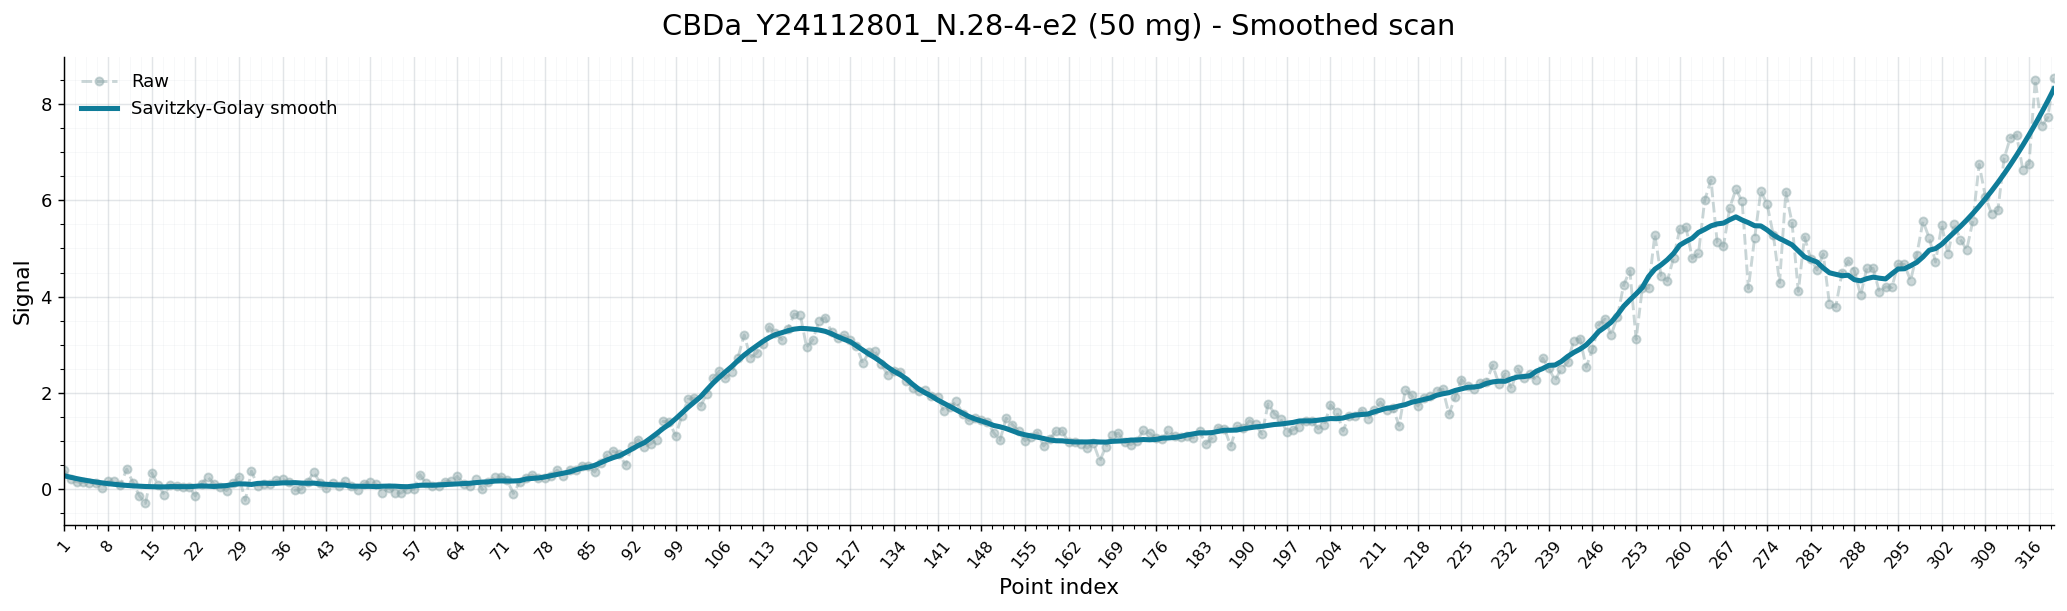

In [82]:
#Code for smoothing using SG filter
from pathlib import Path
import csv

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

csv_path = Path("scans_raw_data.csv")

with csv_path.open(newline="") as handle:
    rows = list(csv.reader(handle))

if len(rows) < 2:
    raise ValueError("Expected at least two CSV rows")

sample_name = rows[1][0]
scan_label = rows[1][1] or "Scan"
x_values = np.array([float(value) for value in rows[0][2:]], dtype=float)
y = np.array([float(value) for value in rows[1][2:]], dtype=float)

if len(x_values) != len(y):
    raise ValueError(f"Axis length ({len(x_values)}) does not match signal length ({len(y)}).")

# Fetching the point index
point_index = np.arange(1, len(y) + 1)

def style_scan_plot(ax, title):
    # Actual plot styles
    ax.set_title(title, fontsize=16, pad=12)
    ax.set_xlabel("Point index", fontsize=12)
    ax.set_ylabel("Signal", fontsize=12)
    ax.set_xlim(1, len(point_index))
    ax.set_xticks(point_index[::7])
    ax.tick_params(axis="x", rotation=50, labelsize=9)
    ax.tick_params(axis="y", labelsize=10)
    ax.minorticks_on()
    ax.grid(True, which="major", color="#9aa4af", alpha=0.28, linewidth=0.8)
    ax.grid(True, which="minor", color="#c6cdd4", alpha=0.14, linewidth=0.5)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

# Choosing the windows as an odd number because of the way
# the filter works by solving least squares in a neighborhood
# of size window_length and then evaluating at the center point.
window_length = 33
polyorder = 3 # Fro this order we can capture assymetries and inflection points

if window_length > len(y):
    window_length = len(y) if len(y) % 2 == 1 else len(y) - 1

if window_length % 2 == 0:
    window_length += 1

#if polyorder >= window_length:
#    raise ValueError("polyorder must be smaller than window_length.")

y_smooth = savgol_filter(y, window_length=window_length, polyorder=polyorder)
print(f"Using window_length={window_length}, polyorder={polyorder}")

# First flat region on smoothed y (used for residual segment and plots below)
flat_window = 50  # number of consecutive points per window (tune)
flat_threshold = 0.008  # max mean(|grad|) to call the window flat (tune to your units)

n = len(y_smooth)
if flat_window < 2:
    raise ValueError("flat_window must be at least 2.")
if flat_window > n:
    raise ValueError("flat_window cannot exceed the series length.")

flat_slice = None  # (start, end) indices into y_smooth, end exclusive
min_mean_grad = np.inf
for i in range(0, n - flat_window + 1):
    segment = y_smooth[i : i + flat_window]
    grad = np.gradient(segment)
    mean_grad = np.mean(np.abs(grad))
    if mean_grad < min_mean_grad:
        min_mean_grad = mean_grad
    if mean_grad <= flat_threshold:
        flat_slice = (i, i + flat_window)
        break

print(f"Minimum mean gradient: {min_mean_grad}")
if flat_slice is not None:
    i0, i1 = flat_slice
    print(
        f"First flat region: point indices [{i0}, {i1 - 1}] "
        f"(1-based point_index {point_index[i0]}–{point_index[i1 - 1]})."
    )
else:
    print("No flat region found (try raising flat_threshold or flat_window).")

fig, ax = plt.subplots(figsize=(16, 4.8), dpi=130)

ax.plot(
    point_index,
    y,
    linestyle="--",
    linewidth=1.6,
    marker="o",
    markersize=4.5,
    color="#8aa5a7",
    alpha=0.45,
    label="Raw",
)
ax.plot(
    point_index,
    y_smooth,
    linestyle="-",
    linewidth=2.8,
    color="#0f7c99",
    label="Savitzky-Golay smooth",
)

style_scan_plot(ax, f"{sample_name} - Smoothed scan")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()



### Flat regions detection

We define a flat region as a region where the mean of the absolute gradient is below a threshold. The threshold is set to 0.008. The window is set to 50 points.

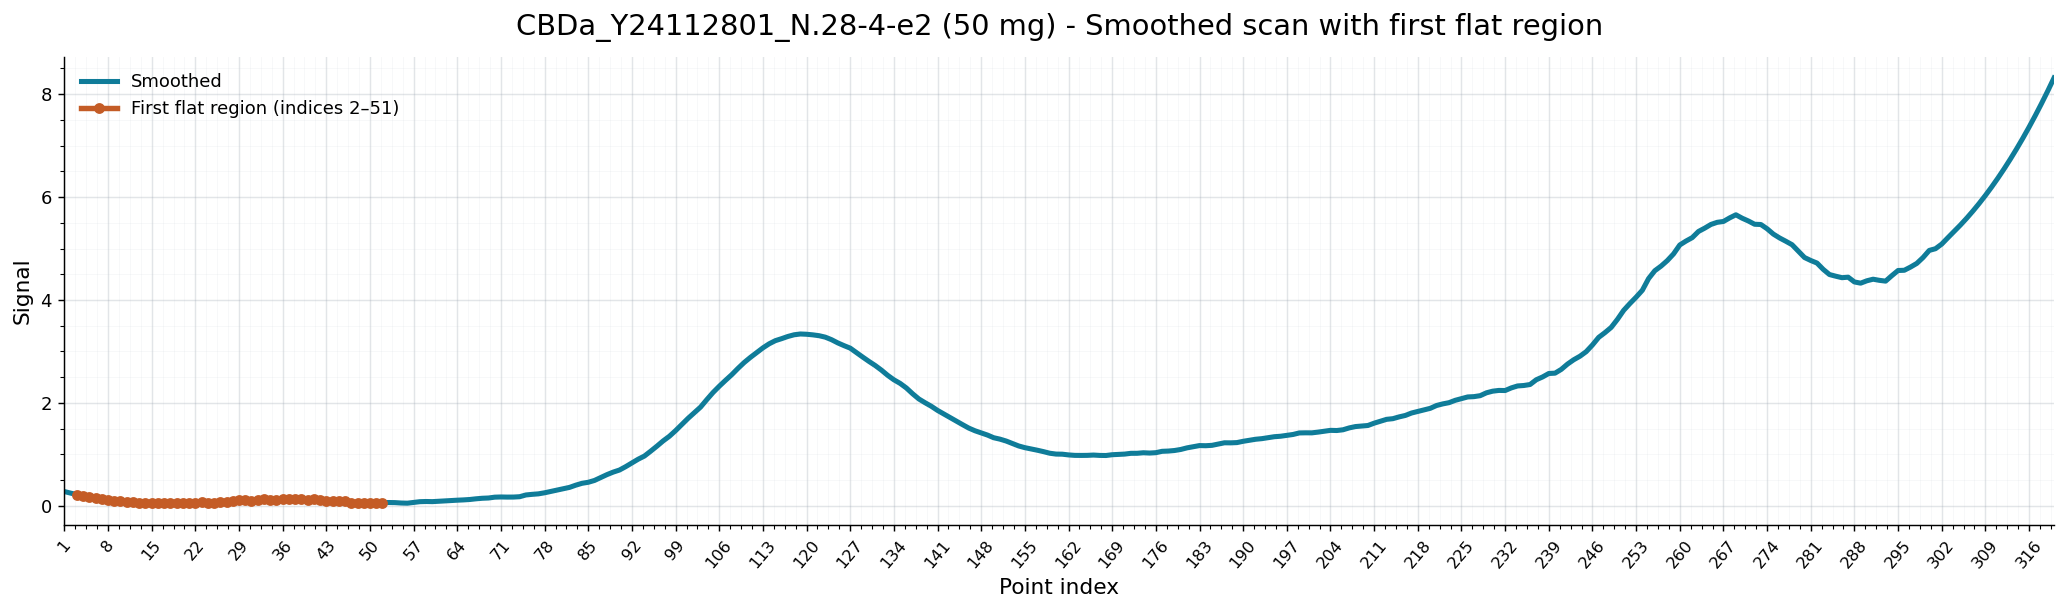

In [83]:
# Flat region highlight (detection runs in the smoothing cell above)
fig, ax = plt.subplots(figsize=(16, 4.8), dpi=130)
ax.plot(
    point_index,
    y_smooth,
    linestyle="-",
    linewidth=2.8,
    color="#0f7c99",
    label="Smoothed",
)
if flat_slice is not None:
    i0, i1 = flat_slice
    ax.plot(
        point_index[i0:i1],
        y_smooth[i0:i1],
        linestyle="-",
        linewidth=3.0,
        marker="o",
        markersize=5,
        color="#c45c26",
        label=f"First flat region (indices {i0}–{i1 - 1})",
        zorder=5,
    )
else:
    print("No flat region found (try raising flat_threshold or flat_window).")

style_scan_plot(ax, f"{sample_name} - Smoothed scan with first flat region")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()
